In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/fake_job_postings.csv')
print("Loaded:", df.shape)
print(df['fraudulent'].value_counts())

Loaded: (17880, 18)
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [2]:
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text) or text is None:
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    return " ".join(tokens)

def build_combined_text(df):
    cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
    combined = df[cols].fillna('').agg(' '.join, axis=1)
    return combined.apply(clean_text)

df['combined_text'] = build_combined_text(df)
print("Sample cleaned text:")
print(df['combined_text'].iloc[0][:200])

Sample cleaned text:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cooks give everything need one place top editorial business engineering team focused using techno


In [3]:
SUSPICIOUS_TITLE_KEYWORDS = [
    'easy money', 'work from home', 'no experience needed',
    'no experience required', 'unlimited earning', 'be your own boss',
    'urgent hiring', 'urgently hiring', 'home based', 'data entry',
    'earn daily', 'part time earn', 'weekly pay guaranteed','flexible hours',
    'virtual assistant needed', 'start immediately', 'immediate start', 'no fee'
]

SUSPICIOUS_DESC_KEYWORDS = [
    'whatsapp us', 'telegram us', 'wire transfer', 'western union',
    'money order', 'no interview', 'guaranteed income',
    'six figure', 'financial freedom'
]

def has_suspicious_keywords(text, keyword_list):
    if pd.isna(text): return 0
    return int(any(kw in text.lower() for kw in keyword_list))

def extract_structured_features(df):
    feats = pd.DataFrame(index=df.index)
    feats['has_salary']          = df['salary_range'].notna().astype(int)
    feats['has_company_profile'] = df['company_profile'].notna().astype(int)
    feats['has_requirements']    = df['requirements'].notna().astype(int)
    feats['has_benefits']        = df['benefits'].notna().astype(int)
    feats['has_logo']            = df['has_company_logo'].fillna(0).astype(int)
    feats['telecommuting']       = df['telecommuting'].fillna(0).astype(int)
    feats['desc_length']         = df['description'].fillna('').apply(len)
    feats['title_word_count']    = df['title'].fillna('').apply(lambda x: len(x.split()))
    feats['suspicious_title']    = df['title'].apply(
        lambda x: has_suspicious_keywords(x, SUSPICIOUS_TITLE_KEYWORDS))
    feats['suspicious_desc']     = df['description'].apply(
        lambda x: has_suspicious_keywords(x, SUSPICIOUS_DESC_KEYWORDS))
    return feats

structured = extract_structured_features(df)
print("Structured features shape:", structured.shape)
print(structured.head())

Structured features shape: (17880, 10)
   has_salary  has_company_profile  has_requirements  has_benefits  has_logo  \
0           0                    1                 1             0         1   
1           0                    1                 1             1         1   
2           0                    1                 1             0         1   
3           0                    1                 1             1         1   
4           0                    1                 1             1         1   

   telecommuting  desc_length  title_word_count  suspicious_title  \
0              0          905                 2                 0   
1              0         2077                 6                 0   
2              0          355                 4                 0   
3              0         2600                 5                 0   
4              0         1520                 3                 0   

   suspicious_desc  
0                0  
1                0  
2 

In [4]:
from sklearn.model_selection import train_test_split

X_text   = df['combined_text']
X_struct = structured.values
y        = df['fraudulent']

X_tr_text, X_te_text,X_tr_struct, X_te_struct,y_train, y_test = train_test_split(X_text, X_struct, y,test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(y_train)} | Test size: {len(y_test)}")
print(f"Fake in train: {y_train.sum()} | Fake in test: {y_test.sum()}")

Train size: 14304 | Test size: 3576
Fake in train: 693 | Fake in test: 173


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import scipy.sparse as sp
from sklearn.preprocessing import MaxAbsScaler

tfidf = TfidfVectorizer(
    max_features=15000,       
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)
X_tr_tfidf = tfidf.fit_transform(X_tr_text)
X_te_tfidf = tfidf.transform(X_te_text)

scaler = MaxAbsScaler()
X_tr_struct_scaled = scaler.fit_transform(X_tr_struct)
X_te_struct_scaled = scaler.transform(X_te_struct)


X_train = sp.hstack([X_tr_tfidf, X_tr_struct_scaled], format='csr')
X_test = sp.hstack([X_te_tfidf, X_te_struct_scaled], format='csr')



In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Fake: {y_train_res.sum()} | Real: {(y_train_res==0).sum()}")

After SMOTE — Fake: 13611 | Real: 13611


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,f1_score, roc_auc_score)

lr = LogisticRegression(C=1.0,max_iter=2000,solver='lbfgs',random_state=42)
lr.fit(X_train_res, y_train_res)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1 (Fake class): {f1_score(y_test, y_pred):.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       1.00      0.98      0.99      3403
        Fake       0.74      0.91      0.82       173

    accuracy                           0.98      3576
   macro avg       0.87      0.95      0.90      3576
weighted avg       0.98      0.98      0.98      3576

ROC-AUC Score: 0.9946
F1 (Fake class): 0.8187


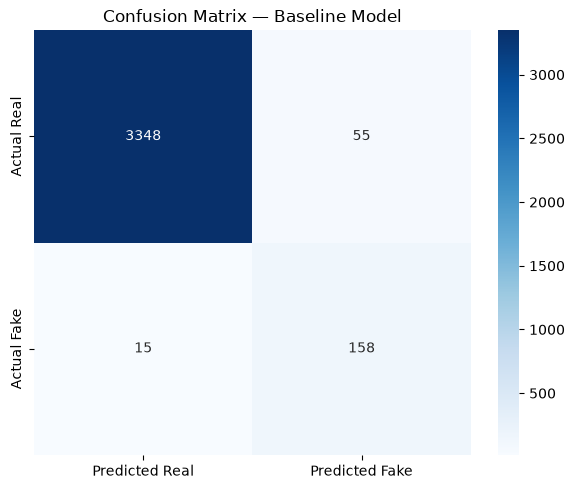

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted Real', 'Predicted Fake'],yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Confusion Matrix — Baseline Model')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150)
plt.show()
plt.close()

In [23]:
feature_names = tfidf.get_feature_names_out().tolist()
structured_names = ['has_salary', 'has_company_profile', 'has_requirements','has_benefits', 'has_logo', 'telecommuting','desc_length', 'title_word_count', 'suspicious_title', 'suspicious_desc'
]
all_features = feature_names + structured_names

coef = lr.coef_[0]
top_fake_idx = np.argsort(coef)[-20:][::-1]
top_real_idx = np.argsort(coef)[:20]

print("\nTop 20 features → FAKE:")
for i in top_fake_idx:
    print(f"  {all_features[i]:30s}  coef={coef[i]:.4f}")

print("\nTop 20 features → REAL:")
for i in top_real_idx:
    print(f"  {all_features[i]:30s}  coef={coef[i]:.4f}")


Top 20 features → FAKE:
  link url                        coef=5.9048
  accion                          coef=4.8335
  link                            coef=4.2886
  high school                     coef=3.6582
  aptitude staffing               coef=3.5886
  earn                            coef=3.4694
  administrative                  coef=3.3936
  money                           coef=3.1665
  leveraging career               coef=3.1508
  administrative assistant        coef=3.0598
  receptionist                    coef=3.0273
  aptitude                        coef=2.9827
  phone                           coef=2.9442
  process provide                 coef=2.7869
  offshore                        coef=2.7092
  hospital                        coef=2.6438
  cash                            coef=2.6307
  refined resources               coef=2.6305
  assistant                       coef=2.6056
  signing bonus                   coef=2.5847

Top 20 features → REAL:
  english                     

In [24]:
import joblib

joblib.dump(lr, "../src/lr_model.pkl")
joblib.dump(tfidf, "../src/tfidf.pkl")
joblib.dump(scaler, "../src/scaler.pkl")

['../src/scaler.pkl']